# Medicare Billing Anomaly Detection (Texas, 2024)

**Goal:** find Texas providers who got paid a lot more per Medicare patient than other providers in the same specialty.

- **Measure:** payment per patient = total Medicare payments / number of Medicare patients
- **What counts as unusual:** a z-score above 3 compared to their own specialty, calculated on a log scale because payments are really skewed

**Data:** CMS "Medicare Physician & Other Practitioners – by Provider" (data.cms.gov), 2024 data year, filtered to individual providers in Texas.

A potential use-case would be identifying fraud. However, an outlier here still might not be fraud. It just means the provider looks different from their peers and might be worth a closer look to determine if that could be the case.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Getting the data

In [2]:
# ran this once on the full national file to make medicare_tx.csv
# (the national file is huge so I only load the Texas one now)
# df = pd.read_csv("MUP_PHY_R26_P05_V10_D24_Prov.csv")
# df = df[df["Rndrng_Prvdr_State_Abrvtn"] == "TX"]
# df = df[df["Rndrng_Prvdr_Ent_Cd"] == "I"]   # I = individual, O = organization
# df.to_csv("medicare_tx.csv", index=False)

In [3]:
df_raw = pd.read_csv("medicare_tx.csv")
print(df_raw.shape)
df_raw.head()

(82081, 81)


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000738,Zumwalt,Juliette,A,P.A.,I,7401 S. Main,NaN,Houston,TX,...,22.0,NaN,75.0,67.0,31.0,15.0,NaN,75.0,9.0,0.7842
1,1003001298,Warren,Kasey,NaN,O.D.,I,5401 South Fm 1626,Suite 135,Kyle,TX,...,29.0,NaN,73.0,75.0,25.0,NaN,NaN,47.0,NaN,0.8445
2,1003001462,Wolski,Michal,J,MD,I,2380 S. I-35e,NaN,Waxahachie,TX,...,36.0,22.0,75.0,75.0,34.0,16.0,NaN,47.0,14.0,1.7777
3,1003002205,Magcalas,Charity,C,CRNA,I,12222 Merit Dr Ste 600,NaN,Dallas,TX,...,26.0,13.0,75.0,75.0,33.0,13.0,NaN,75.0,9.0,1.1962
4,1003002627,Kadiyala,Samatha,K,M.D.,I,506 This Way St,NaN,Lake Jackson,TX,...,31.0,12.0,75.0,75.0,23.0,40.0,NaN,51.0,7.0,0.9826


In [4]:
# each NPI shows up once, so one row = one provider
print(df_raw["Rndrng_NPI"].nunique(), len(df_raw))

82081 82081


In [5]:
# lots of columns, meanings are in the CMS data dictionary
df_raw.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name',
       'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd',
       'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS',
       'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc',
       'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type',
       'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds', 'Tot_Benes',
       'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt',
       'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Drug_Sprsn_Ind',
       'Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug_Tot_Srvcs',
       'Drug_Sbmtd_Chrg', 'Drug_Mdcr_Alowd_Amt', 'Drug_Mdcr_Pymt_Amt',
       'Drug_Mdcr_Stdzd_Amt', 'Med_Sprsn_Ind', 'Med_Tot_HCPCS_Cds',
       'Med_Tot_Benes', 'Med_Tot_Srvcs', 'Med_Sbmtd_Chrg',
       'Med_Mdcr_Alowd_Amt', 'Med_Mdcr_Pymt_Amt', 'Med_Mdcr_Stdzd_Amt',
       'Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_74

## 2. Putting it in SQLite

Column cheat sheet by Claude (the names are hard to read):

| Column | What it means |
|---|---|
| `Rndrng_NPI` | provider's ID number. "Rndrng" = rendering, the provider who actually did the service |
| `Rndrng_Prvdr_Type` | specialty |
| `Rndrng_Prvdr_City` | city |
| `Tot_Benes` | number of different Medicare patients they saw ("benes" = beneficiaries) |
| `Tot_Srvcs` | number of services they billed |
| `Tot_Mdcr_Pymt_Amt` | total $ Medicare actually paid them (after the patient's deductible/coinsurance) |
| `Bene_Avg_Risk_Scre` | how sick their patients are on average (around 1 is average, higher = sicker) |

In [6]:
conn = sqlite3.connect("medicare_tx.db") #make a new db for medicare_tx

cols = ['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_City',
        'Tot_Benes', 'Tot_Srvcs', 'Tot_Mdcr_Pymt_Amt', 'Bene_Avg_Risk_Scre']

# if_exists='replace' so rerunning the cell doesn't error
df_raw[cols].to_sql('providers', conn, if_exists='replace', index=False)

# should be 82,081
pd.read_sql("SELECT COUNT(*) AS n FROM providers", conn)

,n
0,82081


## 3. Exploring with SQL

In [7]:
# which specialties get the most Medicare money overall?
q1 = """
SELECT Rndrng_Prvdr_Type,                     -- specialty
       COUNT(*) AS n_providers,               -- COUNT(*) counts rows, so # of providers here
       SUM(Tot_Mdcr_Pymt_Amt) AS total_paid   -- total $ Medicare paid the whole specialty
FROM providers
GROUP BY Rndrng_Prvdr_Type                    -- one row per specialty
ORDER BY total_paid DESC
LIMIT 10
"""
pd.read_sql(q1, conn)

,Rndrng_Prvdr_Type,n_providers,total_paid
0,Nurse Practitioner,14200,1.077603e+09
1,Internal Medicine,6183,5.991787e+08
2,Ophthalmology,1238,5.989956e+08
3,Hematology-Oncology,613,5.066761e+08
4,Family Practice,6385,4.133077e+08
5,Medical Oncology,393,3.382460e+08
6,Cardiology,1379,3.116740e+08
7,Podiatry,965,2.607631e+08
8,Diagnostic Radiology,2345,2.454465e+08
9,Dermatology,965,2.313813e+08


In [8]:
# average payment per patient by specialty
q2 = """
SELECT Rndrng_Prvdr_Type,
       COUNT(*) AS n_providers,
       AVG(Tot_Mdcr_Pymt_Amt * 1.0 / Tot_Benes) AS avg_pay_per_bene
       -- payment / patients for each provider, then average that across the specialty
       -- *1.0 so sqlite doesn't do integer division (7/2 would give 3)
FROM providers
WHERE Tot_Benes > 0          -- no dividing by 0
GROUP BY Rndrng_Prvdr_Type
HAVING COUNT(*) >= 30        -- WHERE filters rows before grouping, HAVING filters the groups after
ORDER BY avg_pay_per_bene DESC
LIMIT 10
"""
pd.read_sql(q2, conn)

,Rndrng_Prvdr_Type,n_providers,avg_pay_per_bene
0,General Practice,192,3470.229309
1,Medical Oncology,393,2071.522040
2,Hematology-Oncology,613,2048.224523
3,Radiation Oncology,329,1888.860323
4,Rheumatology,382,1685.885825
5,Nuclear Medicine,33,1400.866245
6,Gynecological Oncology,81,1274.851812
7,Podiatry,965,1237.800250
8,Allergy/ Immunology,271,1136.668342
9,Speech Language Pathologist,150,1104.092614


In [9]:
# average services per patient by specialty
q3 = """
SELECT Rndrng_Prvdr_Type,
       COUNT(*) AS n_providers,
       AVG(Tot_Srvcs * 1.0 / Tot_Benes) AS avg_srvcs_per_bene
       -- how services get counted depends on the service (drug units vs office visits etc)
       -- so this only really makes sense comparing similar specialties
FROM providers
WHERE Tot_Benes > 0
GROUP BY Rndrng_Prvdr_Type
HAVING COUNT(*) >= 30
ORDER BY avg_srvcs_per_bene DESC
LIMIT 10
"""
pd.read_sql(q3, conn)

,Rndrng_Prvdr_Type,n_providers,avg_srvcs_per_bene
0,Rheumatology,382,152.061892
1,Hematology-Oncology,613,127.364850
2,Medical Oncology,393,121.598973
3,Hematology,47,58.082743
4,Allergy/ Immunology,271,55.135065
5,Gynecological Oncology,81,54.439159
6,Occupational Therapist in Private Practice,379,46.690134
7,Infectious Disease,425,38.566673
8,Physical Therapist in Private Practice,3579,33.221686
9,Radiation Oncology,329,25.442984


## 4. Finding outliers (pandas)

SQLite doesn't have a built-in standard deviation function, so I did the z-scores in pandas.

In [10]:
df = pd.read_sql("SELECT * FROM providers WHERE Tot_Benes > 0", conn)

df['pay_per_bene'] = df['Tot_Mdcr_Pymt_Amt'] / df['Tot_Benes']
df['log_ppb'] = np.log1p(df['pay_per_bene'])   # payments are super right-skewed

# z-scores aren't reliable for tiny groups, so drop specialties with < 30 providers
counts = df.groupby('Rndrng_Prvdr_Type')['Rndrng_NPI'].transform('count')
df = df[counts >= 30].copy()

# compare each provider to their own specialty, not everyone
grp = df.groupby('Rndrng_Prvdr_Type')['log_ppb']
df['spec_mean'] = grp.transform('mean')
df['spec_std'] = grp.transform('std')
df['z'] = (df['log_ppb'] - df['spec_mean']) / df['spec_std']

# only the high side matters here (z > 3)
df['outlier'] = df['z'] > 3

print(df['outlier'].sum(), "flagged out of", len(df))
print("flag rate:", round(df['outlier'].mean() * 100, 2), "%")
print("NaN z-scores:", df['z'].isna().sum())

887 flagged out of 81895
flag rate: 1.08 %
NaN z-scores: 0


## 5. Looking at the outliers with SQL

In [11]:
# save the results as a second table, flags, so I can join it with providers
df[['Rndrng_NPI', 'z', 'outlier']].to_sql('flags', conn, if_exists='replace', index=False)

pd.read_sql("SELECT COUNT(*) AS n FROM flags", conn)

,n
0,81895


In [12]:
# which specialties have the most outliers?
q4 = """
SELECT p.Rndrng_Prvdr_Type,
       COUNT(*) AS n_providers,
       SUM(f.outlier) AS n_flagged,                          -- True/False got saved as 1/0, so SUM counts the flags
       ROUND(SUM(f.outlier) * 100.0 / COUNT(*), 2) AS pct_flagged
FROM providers p                                             -- p and f are just short names for the tables
JOIN flags f ON p.Rndrng_NPI = f.Rndrng_NPI                  -- match up rows with the same NPI in both tables
GROUP BY p.Rndrng_Prvdr_Type
ORDER BY n_flagged DESC
LIMIT 10
"""
pd.read_sql(q4, conn)

,Rndrng_Prvdr_Type,n_providers,n_flagged,pct_flagged
0,Nurse Practitioner,14200,316,2.23
1,Physician Assistant,6198,72,1.16
2,Internal Medicine,6183,62,1.00
3,Anesthesiology,3259,50,1.53
4,Emergency Medicine,3447,46,1.33
5,Family Practice,6385,45,0.70
6,Diagnostic Radiology,2345,39,1.66
7,Optometry,2428,35,1.44
8,Neurology,1109,19,1.71
9,General Surgery,1477,19,1.29


In [13]:
# the most extreme outliers, with risk score for context
# left NPIs out on purpose since this goes on GitHub and an outlier isn't proof of anything
q5 = """
SELECT p.Rndrng_Prvdr_Type,
       p.Tot_Benes,
       ROUND(p.Tot_Mdcr_Pymt_Amt * 1.0 / p.Tot_Benes, 2) AS pay_per_bene,
       p.Bene_Avg_Risk_Scre,                                 -- sicker patients can explain higher payments
       ROUND(f.z, 2) AS z
FROM providers p
JOIN flags f ON p.Rndrng_NPI = f.Rndrng_NPI
WHERE f.outlier = 1
ORDER BY f.z DESC
LIMIT 10
"""
pd.read_sql(q5, conn)

,Rndrng_Prvdr_Type,Tot_Benes,pay_per_bene,Bene_Avg_Risk_Scre,z
0,Emergency Medicine,68,31231.42,1.3595,16.71
1,Emergency Medicine,353,22744.08,2.9263,15.74
2,Emergency Medicine,129,16513.47,2.8560,14.76
3,Emergency Medicine,450,7516.40,2.6475,12.35
4,Emergency Medicine,839,5604.83,2.6014,11.45
5,Nephrology,321,219425.93,4.1030,11.15
6,Physician Assistant,216,94733.78,2.6380,10.09
7,Physician Assistant,28,81451.23,2.9608,9.86
8,Physician Assistant,13,73536.00,4.1065,9.70
9,Physician Assistant,59,53919.00,0.9801,9.23


## 6. Chart

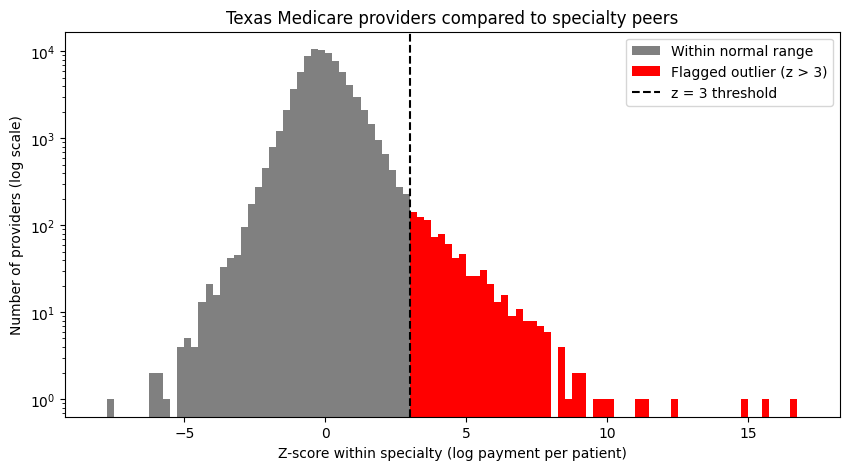

In [14]:
# bins go from the lowest to the highest z
# (my first version stopped at 9 and cut off the biggest outliers)
bins = np.arange(np.floor(df['z'].min()), np.ceil(df['z'].max()) + 0.25, 0.25)

normal = df[df['outlier'] == False]['z']
flagged = df[df['outlier'] == True]['z']

plt.figure(figsize=(10, 5))
plt.hist(normal, bins=bins, color='gray', label='Within normal range')
plt.hist(flagged, bins=bins, color='red', label='Flagged outlier (z > 3)')
plt.axvline(3, color='black', linestyle='--', label='z = 3 threshold')

plt.yscale('log')   # outliers are too small to see otherwise
plt.xlabel('Z-score within specialty (log payment per patient)')
plt.ylabel('Number of providers (log scale)')
plt.title('Texas Medicare providers compared to specialty peers')
plt.legend()

plt.savefig('outlier_histogram.png', dpi=150)   # has to be before show()
plt.show()

In [15]:
conn.close()

## Conclusion

For this project, I looked at 2024 Medicare data for about 82,000 individual providers in Texas to see which ones were paid unusually high amounts per patient compared to other providers in the same specialty. I only included specialties with at least 30 providers, took the log of payment per patient because the data was very skewed, and calculated a z-score for each provider within their specialty. 887 providers (about 1.1%) had a z-score above 3, which is more than I expected, since only about 0.13% would be above 3 if the data followed a normal bell curve. My histogram showed why: most providers were close to their specialty’s average, but there were more extreme high values than a bell curve would predict. It’s important to note that being an outlier doesn’t mean a provider committed fraud. They could have sicker patients or do more expensive procedures than others in their specialty. If I continued this project, I would adjust for how sick each provider’s patients are, use a method that’s less affected by extreme values, and check whether the same providers stand out across multiple years.

Note: I built this project with help from Claude (an AI assistant), which I used as a tutor to learn SQLite and work through the analysis. All of the results, decisions, and conclusions were reviewed and understood by me.